# Search-6-AdversarialSearch : Recherche Adversariale

**Navigation** : [<< Recherche informee](Search-3-Informed.ipynb) | [Index](../README.md) | [MCTS >>](Search-7-MCTS-And-Beyond.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Modeliser** un jeu a somme nulle comme un probleme de recherche
2. **Implementer** l'algorithme Minimax avec l'optimisation Alpha-Beta
3. **Comprendre** les limites de Minimax et les strategies d'amelioration
4. **Appliquer** la recherche iterative (iterative deepening)
5. **Utiliser** les tables de transposition pour optimiser la recherche

### Prerequis
- Notebooks Search-1 (StateSpace) et Search-2 (DFS/BFS)
- Notebook Search-3 (heuristiques)
- Bases de Python : recursivite, classes

### Duree estimee : 60 minutes

In [1]:
# Imports
import sys
import time
import random
from typing import Optional, List, Dict, Tuple, Any, Callable
from copy import deepcopy
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

print("Environnement pret pour la recherche adversariale.")

Environnement pret pour la recherche adversariale.


## 1. Introduction : Jeux a Somme Nulle

### Qu'est-ce qu'un jeu a somme nulle ?

Un **jeu a somme nulle** (zero-sum game) est un jeu ou les gains d'un joueur correspondent exactement aux pertes de l'autre. Le gain total des deux joueurs est toujours zero.

**Exemples classiques :**
- Tic-Tac-Toe (Morpion)
- Echecs
- Go
- Puissance 4 (Connect Four)

### Caracteristiques d'un jeu a information parfaite

| Caracteristique | Description |
|----------------|-------------|
| **Information parfaite** | Les deux joueurs connaissent l'etat complet du jeu |
| **Tour a tour** | Les joueurs jouent alternativement |
| **Deterministe** | Le resultat d'une action est certain (pas de hasard) |
| **Fini** | Le jeu se termine toujours en un nombre fini de coups |

### Formalisation

Un jeu a somme nulle peut etre modelise comme :

- **S** : Ensemble des etats du jeu (positions)
- **s0** : Etat initial
- **Joueur(s)** : Fonction indiquant quel joueur doit jouer dans l'etat s
- **Actions(s)** : Coups legaux dans l'etat s
- **Resultat(s, a)** : Nouvel etat apres avoir joue l'action a
- **EstTerminal(s)** : Le jeu est-il termine ?
- **Utilite(s, p)** : Valeur finale pour le joueur p (-1, 0, +1)

In [2]:
# Classe de base abstraite pour un jeu a somme nulle
from abc import ABC, abstractmethod

class JeuSommeNulle(ABC):
    """Interface pour un jeu a somme nulle a information parfaite."""
    
    @abstractmethod
    def etat_initial(self) -> Any:
        """Retourne l'etat initial du jeu."""
        pass
    
    @abstractmethod
    def joueur(self, etat: Any) -> str:
        """Retourne le joueur qui doit jouer ('MAX' ou 'MIN')."""
        pass
    
    @abstractmethod
    def actions(self, etat: Any) -> List[Any]:
        """Retourne la liste des actions legales."""
        pass
    
    @abstractmethod
    def resultat(self, etat: Any, action: Any) -> Any:
        """Retourne le nouvel etat apres l'action."""
        pass
    
    @abstractmethod
    def est_terminal(self, etat: Any) -> bool:
        """Le jeu est-il termine ?"""
        pass
    
    @abstractmethod
    def utilite(self, etat: Any, joueur: str) -> float:
        """Valeur de l'etat terminal pour le joueur (+1, 0, -1)."""
        pass
    
    @abstractmethod
    def afficher(self, etat: Any) -> str:
        """Representation textuelle de l'etat."""
        pass

## 2. Exemple : Tic-Tac-Toe (Morpion)

Implementons le jeu de Morpour pour illustrer les concepts.

In [3]:
class TicTacToe(JeuSommeNulle):
    """Implementation du jeu de Morpion."""
    
    def __init__(self):
        self._etat_initial = (tuple([' ']*9), 'X')  # (grille 3x3 aplatie, joueur)
    
    def etat_initial(self) -> Tuple[Tuple[str, ...], str]:
        return self._etat_initial
    
    def joueur(self, etat: Tuple[Tuple[str, ...], str]) -> str:
        return 'MAX' if etat[1] == 'X' else 'MIN'
    
    def actions(self, etat: Tuple[Tuple[str, ...], str]) -> List[int]:
        """Retourne les indices des cases vides."""
        grille = etat[0]
        return [i for i in range(9) if grille[i] == ' ']
    
    def resultat(self, etat: Tuple[Tuple[str, ...], str], action: int) -> Tuple[Tuple[str, ...], str]:
        """Joue le coup et retourne le nouvel etat."""
        grille = list(etat[0])
        joueur_actuel = etat[1]
        grille[action] = joueur_actuel
        prochain_joueur = 'O' if joueur_actuel == 'X' else 'X'
        return (tuple(grille), prochain_joueur)
    
    def est_terminal(self, etat: Tuple[Tuple[str, ...], str]) -> bool:
        grille = etat[0]
        lignes = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8],  # lignes
            [0, 3, 6], [1, 4, 7], [2, 5, 8],  # colonnes
            [0, 4, 8], [2, 4, 6]              # diagonales
        ]
        for l in lignes:
            if grille[l[0]] != ' ' and grille[l[0]] == grille[l[1]] == grille[l[2]]:
                return True
        return ' ' not in grille
    
    def utilite(self, etat: Tuple[Tuple[str, ...], str], joueur: str) -> float:
        grille = etat[0]
        lignes = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8],
            [0, 3, 6], [1, 4, 7], [2, 5, 8],
            [0, 4, 8], [2, 4, 6]
        ]
        for l in lignes:
            if grille[l[0]] != ' ' and grille[l[0]] == grille[l[1]] == grille[l[2]]:
                gagnant = 'MAX' if grille[l[0]] == 'X' else 'MIN'
                return 1 if gagnant == joueur else -1
        return 0
    
    def afficher(self, etat: Tuple[Tuple[str, ...], str]) -> str:
        g = etat[0]
        return f"\n{g[0]}|{g[1]}|{g[2]}\n-----\n{g[3]}|{g[4]}|{g[5]}\n-----\n{g[6]}|{g[7]}|{g[8]}\n"

# Test
jeu = TicTacToe()
print(jeu.afficher(jeu.etat_initial()))
print(f"Joueur actuel: {jeu.joueur(jeu.etat_initial())}")
print(f"Actions possibles: {jeu.actions(jeu.etat_initial())}")


 | | 
-----
 | | 
-----
 | | 

Joueur actuel: MAX
Actions possibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]


## 3. L'Algorithme Minimax

### Principe

L'algorithme **Minimax** explore l'arbre de jeu complet jusqu'aux etats terminaux :

- **MAX** cherche a maximiser l'utilite (son tour)
- **MIN** cherche a minimiser l'utilite (tour adverse)

### Pseudo-code

```
fonction MINIMAX(etat):
    si EST_TERMINAL(etat):
        retourner UTILITE(etat)
    
    si JOUEUR(etat) == MAX:
        retourner max(MINIMAX(RESULTAT(etat, a)) pour a dans ACTIONS(etat))
    sinon:
        retourner min(MINIMAX(RESULTAT(etat, a)) pour a dans ACTIONS(etat))
```

In [4]:
def minimax(jeu: JeuSommeNulle, etat: Any, joueur_max: str = 'MAX') -> Tuple[float, Optional[Any]]:
    """
    Algorithme Minimax recursif.
    Retourne (valeur, meilleure_action)
    """
    if jeu.est_terminal(etat):
        return jeu.utilite(etat, joueur_max), None
    
    actions_legales = jeu.actions(etat)
    
    if jeu.joueur(etat) == joueur_max:
        meilleure_valeur = float('-inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = minimax(jeu, nouvel_etat, joueur_max)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
        return meilleure_valeur, meilleure_action
    else:
        meilleure_valeur = float('+inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = minimax(jeu, nouvel_etat, joueur_max)
            if valeur < meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
        return meilleure_valeur, meilleure_action

# Test sur Tic-Tac-Toe
jeu = TicTacToe()
valeur, action = minimax(jeu, jeu.etat_initial())
print(f"Valeur Minimax depuis l'etat initial: {valeur}")
print(f"Meilleure action: {action}")

Valeur Minimax depuis l'etat initial: 0
Meilleure action: 0


### Analyse de complexite

| Metrique | Valeur |
|----------|--------|
| **Complexite temporelle** | O(b^m) ou b = branching factor, m = profondeur max |
| **Complexite spatiale** | O(m) pour la pile de recursion |

Pour le Tic-Tac-Toe : b = 9, m = 9, environ 9! = 362,880 noeuds.

Pour les echecs : b ~ 35, m ~ 100, environ 35^100 noeuds (impossible !)

## 4. L'Elagage Alpha-Beta

### Principe

L'elagage **Alpha-Beta** permet d'eliminer des branches entieres de l'arbre sans changer le resultat.

- **alpha** : meilleure valeur que MAX peut garantir
- **beta** : meilleure valeur que MIN peut garantir

Si alpha >= beta, on peut couper la branche.

### Gain de performance

Avec un ordonnancement optimal : O(b^(m/2)) au lieu de O(b^m).

In [5]:
def alpha_beta(jeu: JeuSommeNulle, etat: Any, alpha: float = float('-inf'), 
               beta: float = float('+inf'), joueur_max: str = 'MAX') -> Tuple[float, Optional[Any]]:
    """
    Algorithme Alpha-Beta pruning.
    """
    if jeu.est_terminal(etat):
        return jeu.utilite(etat, joueur_max), None
    
    actions_legales = jeu.actions(etat)
    
    if jeu.joueur(etat) == joueur_max:
        meilleure_valeur = float('-inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta(jeu, nouvel_etat, alpha, beta, joueur_max)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            alpha = max(alpha, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action
    else:
        meilleure_valeur = float('+inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta(jeu, nouvel_etat, alpha, beta, joueur_max)
            if valeur < meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            beta = min(beta, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action

# Benchmark
jeu = TicTacToe()
start = time.time()
v1, a1 = minimax(jeu, jeu.etat_initial())
t1 = time.time() - start

start = time.time()
v2, a2 = alpha_beta(jeu, jeu.etat_initial())
t2 = time.time() - start

print(f"Minimax: valeur={v1}, temps={t1:.4f}s")
print(f"Alpha-Beta: valeur={v2}, temps={t2:.4f}s")
print(f"Speedup: {t1/t2:.1f}x")

Minimax: valeur=0, temps=1.7881s
Alpha-Beta: valeur=0, temps=0.0643s
Speedup: 27.8x


## 5. Recherche Iterative (Iterative Deepening)

Explore progressivement en augmentant la profondeur. Permet de controler le temps et d'utiliser les resultats des profondeurs precedentes pour ordonner les coups.

In [6]:
def evaluation_heuristique(jeu: JeuSommeNulle, etat: Any, joueur: str) -> float:
    """Fonction d'evaluation pour Tic-Tac-Toe."""
    grille = etat[0]
    mon_symbole = 'X' if joueur == 'MAX' else 'O'
    adv_symbole = 'O' if joueur == 'MAX' else 'X'
    
    lignes = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],
        [0, 3, 6], [1, 4, 7], [2, 5, 8],
        [0, 4, 8], [2, 4, 6]
    ]
    
    score = 0
    for l in lignes:
        ma_ligne = sum(1 for i in l if grille[i] == mon_symbole)
        adv_ligne = sum(1 for i in l if grille[i] == adv_symbole)
        if adv_ligne == 0:
            score += ma_ligne ** 2
        if ma_ligne == 0:
            score -= adv_ligne ** 2
    return score / 9.0

def alpha_beta_limite(jeu, etat, profondeur, alpha, beta, joueur_max='MAX'):
    """Alpha-Beta avec profondeur limitee."""
    if jeu.est_terminal(etat):
        return jeu.utilite(etat, joueur_max), None
    if profondeur == 0:
        return evaluation_heuristique(jeu, etat, joueur_max), None
    
    actions_legales = jeu.actions(etat)
    if jeu.joueur(etat) == joueur_max:
        best_v, best_a = float('-inf'), None
        for action in actions_legales:
            v, _ = alpha_beta_limite(jeu, jeu.resultat(etat, action), profondeur-1, alpha, beta, joueur_max)
            if v > best_v:
                best_v, best_a = v, action
            alpha = max(alpha, best_v)
            if beta <= alpha:
                break
        return best_v, best_a
    else:
        best_v, best_a = float('+inf'), None
        for action in actions_legales:
            v, _ = alpha_beta_limite(jeu, jeu.resultat(etat, action), profondeur-1, alpha, beta, joueur_max)
            if v < best_v:
                best_v, best_a = v, action
            beta = min(beta, best_v)
            if beta <= alpha:
                break
        return best_v, best_a

def iterative_deepening(jeu, etat, temps_max=1.0):
    """Recherche iterative deepening avec limite de temps."""
    start = time.time()
    best_action = None
    best_value = 0
    depth = 1
    
    while time.time() - start < temps_max:
        value, action = alpha_beta_limite(jeu, etat, depth, float('-inf'), float('+inf'))
        best_value, best_action = value, action
        if abs(value) >= 1:  # Victoire certaine
            break
        depth += 1
    
    return best_value, best_action, depth

# Test
v, a, d = iterative_deepening(jeu, jeu.etat_initial(), temps_max=0.5)
print(f"Iterative Deepening: valeur={v:.2f}, action={a}, profondeur={d}")

Iterative Deepening: valeur=0.00, action=0, profondeur=14


## 6. Tables de Transposition

Les **tables de transposition** stockent les resultats des etats deja evalues. Differentes sequences de coups peuvent mener au meme etat (transpositions).

In [7]:
class AlphaBetaTransposition:
    """Alpha-Beta avec table de transposition."""
    
    def __init__(self):
        self.table = {}
        self.stats = {'hits': 0, 'misses': 0}
    
    def rechercher(self, jeu, etat, profondeur, alpha, beta, joueur_max='MAX'):
        h = hash(etat)
        
        if h in self.table:
            cached_v, cached_d, flag = self.table[h]
            if cached_d >= profondeur:
                self.stats['hits'] += 1
                if flag == 'exact':
                    return cached_v, None
        
        self.stats['misses'] += 1
        
        if jeu.est_terminal(etat):
            return jeu.utilite(etat, joueur_max), None
        if profondeur == 0:
            return evaluation_heuristique(jeu, etat, joueur_max), None
        
        actions = jeu.actions(etat)
        if jeu.joueur(etat) == joueur_max:
            best_v, best_a = float('-inf'), None
            for action in actions:
                v, _ = self.rechercher(jeu, jeu.resultat(etat, action), profondeur-1, alpha, beta, joueur_max)
                if v > best_v:
                    best_v, best_a = v, action
                alpha = max(alpha, best_v)
                if beta <= alpha:
                    break
            self.table[h] = (best_v, profondeur, 'exact')
            return best_v, best_a
        else:
            best_v, best_a = float('+inf'), None
            for action in actions:
                v, _ = self.rechercher(jeu, jeu.resultat(etat, action), profondeur-1, alpha, beta, joueur_max)
                if v < best_v:
                    best_v, best_a = v, action
                beta = min(beta, best_v)
                if beta <= alpha:
                    break
            self.table[h] = (best_v, profondeur, 'exact')
            return best_v, best_a

# Test
ab_trans = AlphaBetaTransposition()
start = time.time()
v, a = ab_trans.rechercher(jeu, jeu.etat_initial(), 9, float('-inf'), float('+inf'))
t = time.time() - start

print(f"Alpha-Beta + Transposition: valeur={v}, temps={t:.4f}s")
print(f"Cache: {ab_trans.stats['hits']} hits, {ab_trans.stats['misses']} misses")

Alpha-Beta + Transposition: valeur=0, temps=0.0102s
Cache: 1565 hits, 3010 misses


## 7. Benchmark Comparatif

,Algorithme,Temps (s),Valeur,Speedup
0,Minimax,1.717017,0,1.0x
1,Alpha-Beta,0.050098,0,34.3x
2,Alpha-Beta + Trans,0.008883,0,193.3x


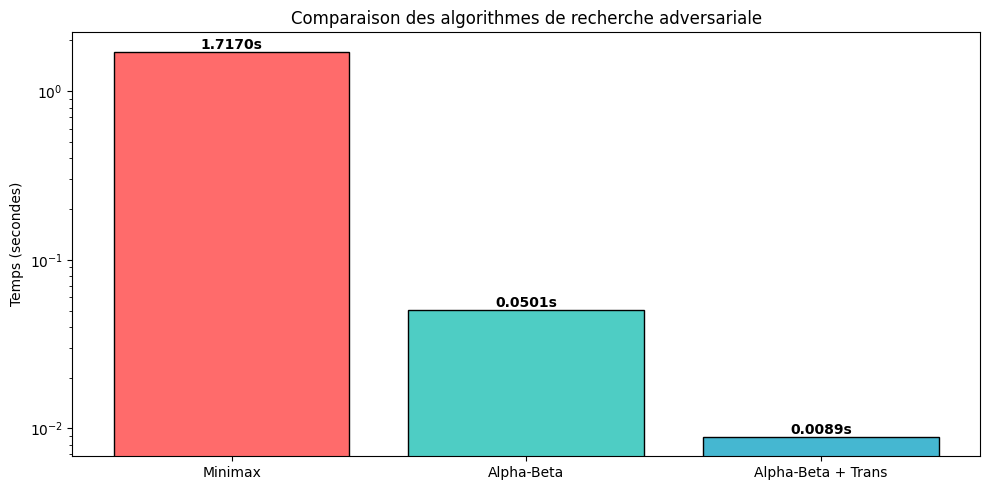

In [8]:
# Benchmark complet
jeu = TicTacToe()
resultats = []

# Test Minimax
start = time.time()
v1, a1 = minimax(jeu, jeu.etat_initial())
t1 = time.time() - start
resultats.append(('Minimax', t1, v1))

# Test Alpha-Beta
start = time.time()
v2, a2 = alpha_beta(jeu, jeu.etat_initial())
t2 = time.time() - start
resultats.append(('Alpha-Beta', t2, v2))

# Test Alpha-Beta + Transposition
ab_trans = AlphaBetaTransposition()
start = time.time()
v3, a3 = ab_trans.rechercher(jeu, jeu.etat_initial(), 9, float('-inf'), float('+inf'))
t3 = time.time() - start
resultats.append(('Alpha-Beta + Trans', t3, v3))

# Affichage
df = pd.DataFrame(resultats, columns=['Algorithme', 'Temps (s)', 'Valeur'])
df['Speedup'] = df['Temps (s)'].apply(lambda x: f"{t1/x:.1f}x")
display(df)

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
algos = [r[0] for r in resultats]
temps = [r[1] for r in resultats]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

bars = ax.bar(algos, temps, color=colors, edgecolor='black')
ax.set_ylabel('Temps (secondes)')
ax.set_title('Comparaison des algorithmes de recherche adversariale')
ax.set_yscale('log')

for bar, t in zip(bars, temps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.4f}s',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Synthese

### Resume des techniques

| Technique | Gain | Complexite |
|-----------|------|------------|
| **Minimax** | Base | O(b^m) |
| **Alpha-Beta** | 2x-10x | O(b^(m/2)) optimal |
| **Transposition Tables** | 2x-5x | Memoire O(n) |
| **Iterative Deepening** | Controle temps | Surcout negligeable |

### Limites

1. **Explosion combinatoire** : Profondeur restreinte
2. **Horizon effect** : Decisions cachees au-dela de la profondeur
3. **Fonction d'evaluation** : Qualite depend de l'heuristique

### Pour aller plus loin

- **MCTS** (Monte Carlo Tree Search) : Explorer intelligemment sans fonction d'evaluation
- **Reseaux de neurones** : AlphaGo, AlphaZero

---

**Navigation** : [<< Recherche informee](Search-3-Informed.ipynb) | [Index](../README.md) | [MCTS >>](Search-7-MCTS-And-Beyond.ipynb)

## Exercices

### Exercice 1 : Connect Four
Implementez une classe `ConnectFour` heritant de `JeuSommeNulle` pour le jeu Puissance 4 (grille 6x7, 4 alignes pour gagner).

### Exercice 2 : Ordonnancement des coups
Ameliorez Alpha-Beta en ordonnant les coups par potentiel decroissant (coups au centre d'abord).

### Exercice 3 : Recherche de Quiescence
Implementez une recherche de quiescence pour eviter l'effet d'horizon.

### Exercice 4 : Zobrist Hashing
Implementez le Zobrist hashing pour optimiser les tables de transposition.

### Exercice 5 : Negamax
Implementez l'algorithme Negamax, une formulation simplifiee de Minimax ou les deux joueurs maximisent de leur propre point de vue. Ajoutez l'elagage Alpha-Beta a votre implementation.

### Exercice 6 : Tournoi algorithmique
Creez un framework de tournoi automatique entre differents algorithmes (aleatoire, Minimax, Alpha-Beta) et analysez les resultats statistiquement.

In [ ]:
# Exercice 6 : Tournoi algorithmique
# TODO: Creez un framework de tournoi automatique entre algorithmes
# - Joueur aleatoire, Minimax, Alpha-Beta jouent les uns contre les autres
# - Chaque paire joue N parties en alternant qui commence (MAX/MIN)
# - Collecter: victoires, nulles, temps moyen par coup
# Indice: creez une fonction jouer_partie(jeu, fn_max, fn_min) -> resultat

def joueur_aleatoire(jeu, etat):
    """Choisit un coup au hasard parmi les actions legales."""
    # TODO: Retourner une action aleatoire
    pass

def joueur_minimax_fn(jeu, etat):
    """Choisit le coup optimal selon Minimax."""
    # TODO: Utiliser la fonction minimax definie plus haut
    pass

def joueur_alphabeta_fn(jeu, etat):
    """Choisit le coup optimal selon Alpha-Beta."""
    # TODO: Utiliser la fonction alpha_beta definie plus haut
    pass

def jouer_partie(jeu, fn_joueur_max, fn_joueur_min):
    """
    Joue une partie complete entre deux fonctions de decision.
    Retourne ('MAX', 'MIN', ou 'NUL') et le nombre de coups joues.
    """
    # TODO: Boucle de jeu jusqu'a etat terminal
    # A chaque tour, appeler fn_joueur_max ou fn_joueur_min selon le joueur
    pass

def tournoi_round_robin(jeu, joueurs_dict, parties_par_paire=10):
    """
    Organise un tournoi round-robin.
    joueurs_dict: {'Aleatoire': fn, 'Minimax': fn, 'AlphaBeta': fn}
    Retourne un DataFrame avec les statistiques (victoires, nulles, defaites).
    """
    # TODO: Pour chaque paire, jouer parties_par_paire parties
    # Alterner qui joue MAX et qui joue MIN
    # Construire un tableau de resultats
    pass

raise NotImplementedError("A vous de jouer !")

---

In [ ]:
# Exercice 5 : Negamax
# Formulation simplifiee de Minimax ou les deux joueurs maximisent de leur point de vue.
# Relation cle : negamax(etat) = max(-negamax(resultat(etat, a)) pour a dans actions)
# L'utilite est multipliee par un facteur de signe (+1 ou -1).

def negamax(jeu, etat, signe=1):
    """
    Algorithme Negamax (Minimax simplifie).
    
    Args:
        jeu: instance de JeuSommeNulle
        etat: etat courant du jeu
        signe: +1 si MAX joue, -1 si MIN joue
    
    Returns:
        (valeur, meilleure_action) du point de vue du joueur courant
    """
    if jeu.est_terminal(etat):
        # Utilite du point de vue du joueur courant
        return signe * jeu.utilite(etat, 'MAX'), None
    
    meilleure_valeur = float('-inf')
    meilleure_action = None
    
    for action in jeu.actions(etat):
        nouvel_etat = jeu.resultat(etat, action)
        valeur, _ = negamax(jeu, nouvel_etat, -signe)
        valeur = -valeur  # Inversion du point de vue
        if valeur > meilleure_valeur:
            meilleure_valeur = valeur
            meilleure_action = action
    
    return meilleure_valeur, meilleure_action

def negamax_alpha_beta(jeu, etat, alpha, beta, signe=1):
    """
    Negamax avec elagage Alpha-Beta.
    
    La formulation Negamax simplifie la gestion MAX/MIN :
    - Un seul cas au lieu de deux
    - Bornes inversees a chaque appel recursif (-beta, -alpha)
    
    Args:
        jeu: instance de JeuSommeNulle
        etat: etat courant du jeu
        alpha: meilleure valeur garantissable par le joueur courant
        beta: meilleure valeur garantissable par l'adversaire
        signe: +1 si MAX joue, -1 si MIN joue
    
    Returns:
        (valeur, meilleure_action)
    """
    if jeu.est_terminal(etat):
        return signe * jeu.utilite(etat, 'MAX'), None
    
    meilleure_valeur = float('-inf')
    meilleure_action = None
    
    for action in jeu.actions(etat):
        nouvel_etat = jeu.resultat(etat, action)
        valeur, _ = negamax_alpha_beta(jeu, nouvel_etat, -beta, -alpha, -signe)
        valeur = -valeur
        if valeur > meilleure_valeur:
            meilleure_valeur = valeur
            meilleure_action = action
        alpha = max(alpha, meilleure_valeur)
        if alpha >= beta:
            break  # Coupure beta
    
    return meilleure_valeur, meilleure_action

# Test : comparer Negamax avec Minimax
jeu = TicTacToe()
etat0 = jeu.etat_initial()

# Minimax classique
start = time.time()
v_mm, a_mm = minimax(jeu, etat0)
t_mm = time.time() - start

# Negamax
start = time.time()
v_nm, a_nm = negamax(jeu, etat0, signe=1)
t_nm = time.time() - start

# Negamax + Alpha-Beta
start = time.time()
v_nmab, a_nmab = negamax_alpha_beta(jeu, etat0, float('-inf'), float('+inf'), signe=1)
t_nmab = time.time() - start

print(f"Minimax:          valeur={v_mm}, action={a_mm}, temps={t_mm:.4f}s")
print(f"Negamax:          valeur={v_nm}, action={a_nm}, temps={t_nm:.4f}s")
print(f"Negamax+AlphaBeta: valeur={v_nmab}, action={a_nmab}, temps={t_nmab:.4f}s")
print(f"\nCohherence des resultats:")
print(f"  Minimax == Negamax: {v_mm == v_nm}")
print(f"  Negamax == NegamaxAB: {v_nm == v_nmab}")

---

In [ ]:
# Exercice 4 : Zobrist Hashing
# Optimisation des tables de transposition via un hash incremental.
# Chaque (position, joueur) est associe a un nombre aleatoire 64 bits.
# Le hash d'un etat est le XOR des positions occupees.

import random

class ZobristHash:
    """Gestionnaire de Zobrist hashing pour Connect Four (ou tout jeu sur grille)."""
    
    def __init__(self, lignes=6, colonnes=7):
        """Initialise la table de hashing avec des nombres aleatoires 64 bits.
        
        Args:
            lignes: nombre de lignes de la grille
            colonnes: nombre de colonnes de la grille
        """
        # Table[ligne][colonne][joueur_index]
        # joueur_index: 0 pour X (MAX), 1 pour O (MIN)
        random.seed(42)  # Reproductibilite pour les tests
        self.lignes = lignes
        self.colonnes = colonnes
        self.table = [
            [
                [random.getrandbits(64) for _ in range(2)]
                for _ in range(colonnes)
            ]
            for _ in range(lignes)
        ]
    
    def hash_etat(self, etat):
        """Calcule le hash Zobrist d'un etat complet.
        
        Args:
            etat: tuple (grille, joueur) ou grille est un tuple de tuples
        
        Returns:
            int: hash 64 bits de l'etat
        """
        grille = etat[0]
        h = 0
        for ligne in range(len(grille)):
            for col in range(len(grille[ligne])):
                case = grille[ligne][col]
                if case != ' ':
                    joueur_idx = 0 if case == 'X' else 1
                    h ^= self.table[ligne][col][joueur_idx]
        return h
    
    def hash_apres_coup(self, hash_actuel, ligne, colonne, joueur):
        """Met a jour le hash de maniere incrementale apres un coup.
        
        Au lieu de recalculer le hash complet, on XOR avec la nouvelle position.
        C'est une operation O(1) au lieu de O(n*m).
        
        Args:
            hash_actuel: hash de l'etat avant le coup
            ligne: ligne ou le pion a ete place
            colonne: colonne ou le pion a ete place
            joueur: 'X' ou 'O'
        
        Returns:
            int: nouveau hash
        """
        joueur_idx = 0 if joueur == 'X' else 1
        return hash_actuel ^ self.table[ligne][colonne][joueur_idx]

# Test sur Tic-Tac-Toe (grille 3x3)
zobrist_ttt = ZobristHash(lignes=3, colonnes=3)

# Etat initial : hash = 0 (aucune position occupee)
jeu_ttt = TicTacToe()
etat0 = jeu_ttt.etat_initial()
h0 = zobrist_ttt.hash_etat(etat0)
print(f"Hash etat initial: {h0}")

# Apres un coup : hash complet vs hash incremental
etat1 = jeu_ttt.resultat(etat0, 4)  # X au centre (ligne 1, col 1)
h1_complet = zobrist_ttt.hash_etat(etat1)
h1_incr = zobrist_ttt.hash_apres_coup(h0, 1, 1, 'X')
print(f"Hash apres X au centre (complet):     {h1_complet}")
print(f"Hash apres X au centre (incremental): {h1_incr}")
print(f"Correspondance: {h1_complet == h1_incr}")

# Verifier que deux etats differents ont des hashes differents
etat2 = jeu_ttt.resultat(etat0, 0)  # X en coin (ligne 0, col 0)
h2 = zobrist_ttt.hash_etat(etat2)
print(f"\nHash apres X coin (0,0): {h2}")
print(f"Hashes differents: {h1_complet != h2}")

# Test sur Connect Four
zobrist_cf = ZobristHash(lignes=6, colonnes=7)
cf = ConnectFour()
etat_cf0 = cf.etat_initial()
h_cf0 = zobrist_cf.hash_etat(etat_cf0)
etat_cf1 = cf.resultat(etat_cf0, 3)
h_cf1 = zobrist_cf.hash_etat(etat_cf1)
print(f"\nConnect Four - Hash initial: {h_cf0}")
print(f"Connect Four - Hash apres X col 3: {h_cf1}")

---

In [ ]:
# Exercice 3 : Recherche de Quiescence
# Evite l'effet d'horizon en continuant la recherche si la position est "instable".
# Une position instable presente des coups qui changent significativement l'evaluation.

def est_position_quiete(jeu, etat, seuil=0.5):
    """Verifie si la position est calme (pas de gain immediat important)."""
    if jeu.est_terminal(etat):
        return True
    # Evaluer la position et ses successeurs
    for action in jeu.actions(etat):
        nouvel_etat = jeu.resultat(etat, action)
        if jeu.est_terminal(nouvel_etat):
            # Un coup peut mener a un etat terminal : position non quiete
            return False
        eval_nouveau = evaluation_heuristique(jeu, nouvel_etat, jeu.joueur(etat))
        eval_actuel = evaluation_heuristique(jeu, etat, jeu.joueur(etat))
        if abs(eval_nouveau - eval_actuel) > seuil:
            return False
    return True

def alpha_beta_quiescence(jeu, etat, profondeur, alpha, beta, joueur_max='MAX'):
    """Alpha-Beta avec recherche de quiescence pour eviter l'effet d'horizon."""
    if jeu.est_terminal(etat):
        return jeu.utilite(etat, joueur_max), None
    
    # Si profondeur atteinte mais position instable, continuer la recherche
    if profondeur == 0:
        if est_position_quiete(jeu, etat, seuil=0.5):
            return evaluation_heuristique(jeu, etat, joueur_max), None
        # Sinon, continuer avec une profondeur limitee supplementaire
        return alpha_beta_quiescence(jeu, etat, 2, alpha, beta, joueur_max)
    
    actions_legales = jeu.actions(etat)
    
    if jeu.joueur(etat) == joueur_max:
        meilleure_valeur = float('-inf')
        meilleure_action = None
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta_quiescence(jeu, nouvel_etat, profondeur - 1,
                                               alpha, beta, joueur_max)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            alpha = max(alpha, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action
    else:
        meilleure_valeur = float('+inf')
        meilleure_action = None
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta_quiescence(jeu, nouvel_etat, profondeur - 1,
                                               alpha, beta, joueur_max)
            if valeur < meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            beta = min(beta, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action

# Test sur Tic-Tac-Toe avec profondeur limitee
jeu = TicTacToe()

# Comparaison : alpha-beta limite simple vs quiescence
v_lim, a_lim = alpha_beta_limite(jeu, jeu.etat_initial(), 3,
                                  float('-inf'), float('+inf'))
v_quie, a_quie = alpha_beta_quiescence(jeu, jeu.etat_initial(), 3,
                                         float('-inf'), float('+inf'))

print(f"Alpha-Beta profondeur 3: valeur={v_lim:.3f}, action={a_lim}")
print(f"Quiescence profondeur 3: valeur={v_quie:.3f}, action={a_quie}")
print(f"(Quiescence continue la recherche si la position est instable)")

---

In [ ]:
# Exercice 2 : Ordonnancement des coups
# Amelioration d'Alpha-Beta en ordonnant les coups par proximite au centre.
# Les coups centraux sont generalement meilleurs car ils offrent plus de possibilites.

def ordonner_actions(actions, centre=3):
    """Ordonne les actions par proximite au centre (distance croissante)."""
    return sorted(actions, key=lambda col: abs(col - centre))

def alpha_beta_ordonne(jeu, etat, alpha=float('-inf'), beta=float('+inf'), joueur_max='MAX'):
    """Alpha-Beta avec ordonnancement des coups pour meilleur elagage."""
    if jeu.est_terminal(etat):
        return jeu.utilite(etat, joueur_max), None
    
    # Ordonner les actions : coups centraux en premier
    actions_legales = ordonner_actions(jeu.actions(etat), centre=3)
    
    if jeu.joueur(etat) == joueur_max:
        meilleure_valeur = float('-inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta_ordonne(jeu, nouvel_etat, alpha, beta, joueur_max)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            alpha = max(alpha, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action
    else:
        meilleure_valeur = float('+inf')
        meilleure_action = None
        
        for action in actions_legales:
            nouvel_etat = jeu.resultat(etat, action)
            valeur, _ = alpha_beta_ordonne(jeu, nouvel_etat, alpha, beta, joueur_max)
            if valeur < meilleure_valeur:
                meilleure_valeur = valeur
                meilleure_action = action
            beta = min(beta, meilleure_valeur)
            if beta <= alpha:
                break
        return meilleure_valeur, meilleure_action

# Test : comparer l'ordonnancement sur Tic-Tac-Toe
jeu = TicTacToe()
etat_test = jeu.etat_initial()

start = time.time()
v_ab, a_ab = alpha_beta(jeu, etat_test)
t_ab = time.time() - start

start = time.time()
v_ord, a_ord = alpha_beta_ordonne(jeu, etat_test)
t_ord = time.time() - start

print(f"Alpha-Beta standard:  valeur={v_ab}, action={a_ab}, temps={t_ab:.4f}s")
print(f"Alpha-Beta ordonne:   valeur={v_ord}, action={a_ord}, temps={t_ord:.4f}s")
print(f"Speedup: {t_ab/t_ord:.1f}x")
print(f"\nVerif ordonnancement: {ordonner_actions([0, 1, 2, 3, 4, 5, 6], centre=3)}")

---

In [ ]:
# Exercice 1 : Connect Four
# Implementation de la classe ConnectFour heritant de JeuSommeNulle
# - Grille 6 lignes x 7 colonnes
# - 4 pions alignes (horizontal, vertical, diagonal) pour gagner
# - Les coups se jouent en choisissant une colonne (le pion tombe)

class ConnectFour(JeuSommeNulle):
    """Jeu de Puissance 4."""
    
    LIGNES = 6
    COLONNES = 7
    
    def etat_initial(self):
        """Retourne l'etat initial : grille vide, joueur X commence."""
        grille_vide = tuple(tuple(' ' * self.COLONNES) for _ in range(self.LIGNES))
        return (grille_vide, 'X')
    
    def joueur(self, etat):
        """Retourne 'MAX' si c'est a X de jouer, 'MIN' sinon."""
        return 'MAX' if etat[1] == 'X' else 'MIN'
    
    def actions(self, etat):
        """Retourne les colonnes jouables (celles non pleines)."""
        grille = etat[0]
        colonnes_jouables = []
        for col in range(self.COLONNES):
            if grille[0][col] == ' ':  # La ligne du haut est libre dans cette colonne
                colonnes_jouables.append(col)
        return colonnes_jouables
    
    def _trouver_ligne(self, grille, colonne):
        """Trouve la ligne ou le pion va tomber dans la colonne donnee."""
        for ligne in range(self.LIGNES - 1, -1, -1):
            if grille[ligne][colonne] == ' ':
                return ligne
        return -1  # Colonne pleine
    
    def resultat(self, etat, action):
        """Joue le coup dans la colonne 'action' et retourne le nouvel etat."""
        grille = [list(ligne) for ligne in etat[0]]
        joueur_actuel = etat[1]
        ligne = self._trouver_ligne(grille, action)
        grille[ligne][action] = joueur_actuel
        prochain_joueur = 'O' if joueur_actuel == 'X' else 'X'
        return (tuple(tuple(ligne) for ligne in grille), prochain_joueur)
    
    def _verifier_alignement(self, grille, ligne, col, dl, dc):
        """Verifie un alignement de 4 dans la direction (dl, dc)."""
        symbole = grille[ligne][col]
        if symbole == ' ':
            return False
        for i in range(1, 4):
            nl, nc = ligne + dl * i, col + dc * i
            if nl < 0 or nl >= self.LIGNES or nc < 0 or nc >= self.COLONNES:
                return False
            if grille[nl][nc] != symbole:
                return False
        return True
    
    def est_terminal(self, etat):
        """Verifie victoire ou grille pleine."""
        grille = etat[0]
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]  # horizontal, vertical, 2 diagonales
        for ligne in range(self.LIGNES):
            for col in range(self.COLONNES):
                for dl, dc in directions:
                    if self._verifier_alignement(grille, ligne, col, dl, dc):
                        return True
        # Grille pleine ?
        return all(grille[0][col] != ' ' for col in range(self.COLONNES))
    
    def utilite(self, etat, joueur):
        """Retourne +1 si le joueur a gagne, -1 s'il a perdu, 0 sinon."""
        grille = etat[0]
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for ligne in range(self.LIGNES):
            for col in range(self.COLONNES):
                for dl, dc in directions:
                    if self._verifier_alignement(grille, ligne, col, dl, dc):
                        gagnant = 'MAX' if grille[ligne][col] == 'X' else 'MIN'
                        return 1 if gagnant == joueur else -1
        return 0
    
    def afficher(self, etat):
        """Retourne une representation textuelle de la grille."""
        grille = etat[0]
        lignes = []
        for ligne in grille:
            lignes.append('|' + '|'.join(ligne) + '|')
        lignes.append('-' * (2 * self.COLONNES + 1))
        lignes.append(' ' + ' '.join(str(c) for c in range(self.COLONNES)))
        return '\n'.join(lignes)

# Test rapide
cf = ConnectFour()
etat0 = cf.etat_initial()
print("Etat initial du Puissance 4 :")
print(cf.afficher(etat0))
print(f"\nJoueur: {cf.joueur(etat0)}")
print(f"Actions possibles: {cf.actions(etat0)}")

# Tester un coup
etat1 = cf.resultat(etat0, 3)  # X joue au centre
print(f"\nApres X en colonne 3 :")
print(cf.afficher(etat1))